In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [4]:
os.chdir("/Users/kaiping/Desktop/olist_project/data") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data'

In [5]:
df_translation = pd.read_csv("raw/product_category_name_translation.csv")
df_sellers     = pd.read_csv("raw/olist_sellers_dataset.csv")
df_products    = pd.read_csv("raw/olist_products_dataset.csv")
df_orders      = pd.read_csv("raw/olist_orders_dataset.csv")
df_order_reviews  = pd.read_csv("raw/olist_order_reviews_dataset.csv")
df_order_payments = pd.read_csv("raw/olist_order_payments_dataset.csv")
df_order_items    = pd.read_csv("raw/olist_order_items_dataset.csv")
df_geolocation    = pd.read_csv("raw/olist_geolocation_dataset.csv")
df_customers      = pd.read_csv("raw/olist_customers_dataset.csv")


In [6]:
tables = {
    "translation": df_translation,
    "sellers": df_sellers,
    "products": df_products,
    "orders": df_orders,
    "order_reviews": df_order_reviews,
    "order_payments": df_order_payments,
    "order_items": df_order_items,
    "geolocation": df_geolocation,
    "customers": df_customers
}


### 1. 篩選orders_delivered_base  
- order表join customer表
- 篩選: order_status = delivered
- customer口徑選： customer表的customer_unique_id

In [66]:
# 0. order_status 比例分析
(df_orders["order_status"]
 .value_counts(normalize=True)
 .mul(100)
 .round(1)
)




order_status
delivered      97.0
shipped         1.1
canceled        0.6
unavailable     0.6
invoiced        0.3
processing      0.3
created         0.0
approved        0.0
Name: proportion, dtype: float64

In [54]:
# 1. customer 表只取需要欄位，避免 join 太多沒必要欄位

customer_map = df_customers[["customer_id", "customer_unique_id"]].copy() 


In [55]:
# 2. orders 表先篩選 delivered

orders_delivered = df_orders.loc[
    df_orders["order_status"].eq("delivered"),
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

In [56]:
# 3. join customer 表，補上 customer_unique_id
orders_delivered_base = orders_delivered.merge(
    customer_map,
    on="customer_id",
    how="left",
    validate="many_to_one"   # 多筆 orders 對一筆 customer
)

In [57]:
# 4. 欄位順序整理
orders_delivered_base = orders_delivered_base[
    [
        "order_id",
        "customer_id",
        "customer_unique_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

In [58]:
# 5. 時間欄位轉 datetime
datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in datetime_cols:
    orders_delivered_base[col] = pd.to_datetime(
        orders_delivered_base[col],
        errors="coerce"
    )

In [60]:
# 檢查結果
print(orders_delivered_base.shape)


(96478, 9)


In [63]:
orders_delivered_base.head()


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26


In [62]:
print(orders_delivered_base.isna().sum())

order_id                          0
customer_id                       0
customer_unique_id                0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64


In [64]:
# 檢查 join 後是否有缺 customer_unique_id
print("missing customer_unique_id:", orders_delivered_base["customer_unique_id"].isna().sum())

# 檢查 order_id 是否仍唯一
print("order_id duplicated:", orders_delivered_base["order_id"].duplicated().sum())


missing customer_unique_id: 0
order_id duplicated: 0


In [96]:
os.chdir("/Users/kaiping/Desktop/olist_project/data/interim")

orders_delivered_base_output_path = Path("orders_delivered_base.csv")

if not orders_delivered_base_output_path.exists():
    orders_delivered_base.to_csv(orders_delivered_base_output_path, index=False, encoding="utf-8-sig")
    print(f"已儲存：{orders_delivered_base_output_path}（位於 {os.getcwd()}）")
else:
    print(f"已存在，未覆蓋：{orders_delivered_base_output_path}（位於 {os.getcwd()}）")

已儲存：orders_delivered_base.csv（位於 /Users/kaiping/Desktop/olist_project/data/interim）


### 1.資料時間覆蓋確認

In [67]:
delivered_rows = len(orders_delivered_base)
min_purchase_ts = orders_delivered_base["order_purchase_timestamp"].min()
max_purchase_ts = orders_delivered_base["order_purchase_timestamp"].max()

print("delivered rows:", delivered_rows)
print("min order_purchase_timestamp:", min_purchase_ts)
print("max order_purchase_timestamp:", max_purchase_ts)

delivered rows: 96478
min order_purchase_timestamp: 2016-09-15 12:16:00
max order_purchase_timestamp: 2018-08-29 15:00:00


### 2.計算每月訂單數

In [68]:
# 建立月份欄位
orders_delivered_base["purchase_month"] = (
    orders_delivered_base["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [69]:
# 每月訂單數量表
monthly_orders = (
    orders_delivered_base
    .groupby("purchase_month", as_index=False)
    .agg(monthly_orders=("order_id", "count"))
    .sort_values("purchase_month")
    .reset_index(drop=True)
)

In [70]:
monthly_orders

,purchase_month,monthly_orders
0,2016-09-01,1
1,2016-10-01,265
2,2016-12-01,1
3,2017-01-01,750
4,2017-02-01,1653
5,2017-03-01,2546
6,2017-04-01,2303
7,2017-05-01,3546
8,2017-06-01,3135
9,2017-07-01,3872


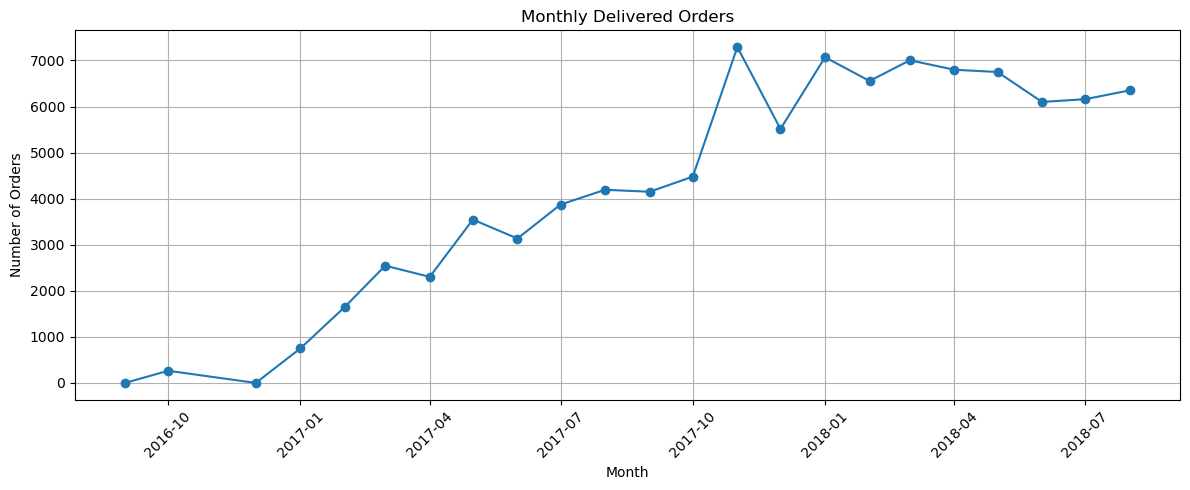

In [71]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["purchase_month"], monthly_orders["monthly_orders"], marker="o")
plt.title("Monthly Delivered Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


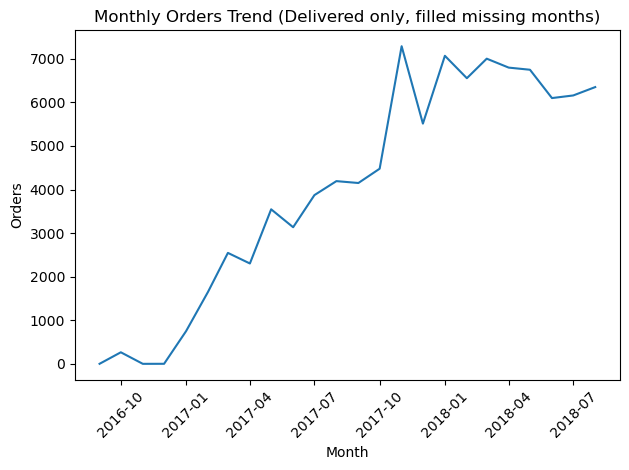

In [23]:
full_months = pd.date_range(
    monthly_orders_delivered["month"].min(),
    monthly_orders_delivered["month"].max(),
    freq="MS"
)

monthly_orders_delivered_full = (
    monthly_orders_delivered.set_index("month")
                           .reindex(full_months)
                           .rename_axis("month")
                           .reset_index()
)

monthly_orders_delivered_full["monthly_orders"] = monthly_orders_delivered_full["monthly_orders"].fillna(0).astype(int)

plt.figure()
plt.plot(monthly_orders_delivered_full["month"], monthly_orders_delivered_full["monthly_orders"])
plt.title("Monthly Orders Trend (Delivered only, filled missing months)")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3. 避免右邊截尾分析

In [87]:
N = 90

# 1. 資料截止日
data_end = orders_delivered_base["order_purchase_timestamp"].max()

# 2. 分析截止日 = data_end - 90天
analysis_end = data_end - pd.Timedelta(days=N)

# 3. 找出右截尾風險訂單
right_censored_orders = orders_delivered_base[
    orders_delivered_base["order_purchase_timestamp"] > analysis_end
].copy()

# 4. 右截尾風險訂單數
risk_customers = right_censored_orders["customer_unique_id"].nunique()

# 5. 全部顧訂單數
total_customers = orders_delivered_base["customer_unique_id"].nunique()

# 6. 風險顧訂單比
risk_ratio = risk_customers / total_customers

# 7. 輸出
print(f"data_end: {data_end}")
print(f"analysis_end (data_end - N): {analysis_end}")
print(f"右截尾風險顧客數量佔比: {risk_customers} / {total_customers} ({risk_ratio:.2%})")

data_end: 2018-08-29 15:00:00
analysis_end (data_end - N): 2018-05-31 15:00:00
右截尾風險顧客數量佔比: 18459 / 93358 (19.77%)


### 4. 活躍顧客分析 (定義：活躍顧客 = 在某個月底往前回溯 90 天內，至少有 1 筆 delivered 訂單的去重複 customer_unique_id 數量。
衡量的是當期活躍顧客池大小

In [74]:
# 只保留分析必要欄位，避免干擾
df_act = orders_delivered_base[
    ["customer_unique_id", "order_purchase_timestamp"]
].dropna(subset=["customer_unique_id", "order_purchase_timestamp"]).copy()

# 建立每個月月底序列
min_date = df_act["order_purchase_timestamp"].min()
max_date = df_act["order_purchase_timestamp"].max()

month_ends = pd.date_range(
    start=min_date.to_period("M").to_timestamp("M"),
    end=max_date.to_period("M").to_timestamp("M"),
    freq="M"
)

# 計算每月月底回溯 90 天內的活躍顧客數
active_rows = []

for month_end in month_ends:
    window_start = month_end - pd.Timedelta(days=89)
    
    active_customers_90 = df_act.loc[
        (df_act["order_purchase_timestamp"] >= window_start) &
        (df_act["order_purchase_timestamp"] <= month_end),
        "customer_unique_id"
    ].nunique()
    
    active_rows.append({
        "month_end": month_end,
        "window_start": window_start,
        "active_customers_90": active_customers_90
    })

monthly_active_90 = pd.DataFrame(active_rows)

monthly_active_90


/var/folders/vl/wskb2r0j55g_xcyvprs302bc0000gn/T/ipykernel_51125/3090392997.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_ends = pd.date_range(


,month_end,window_start,active_customers_90
0,2016-09-30,2016-07-03,1
1,2016-10-31,2016-08-03,263
2,2016-11-30,2016-09-02,263
3,2016-12-31,2016-10-03,263
4,2017-01-31,2016-11-03,657
5,2017-02-28,2016-12-01,2293
6,2017-03-31,2017-01-01,4780
7,2017-04-30,2017-01-31,6389
8,2017-05-31,2017-03-03,7958
9,2017-06-30,2017-04-02,8637


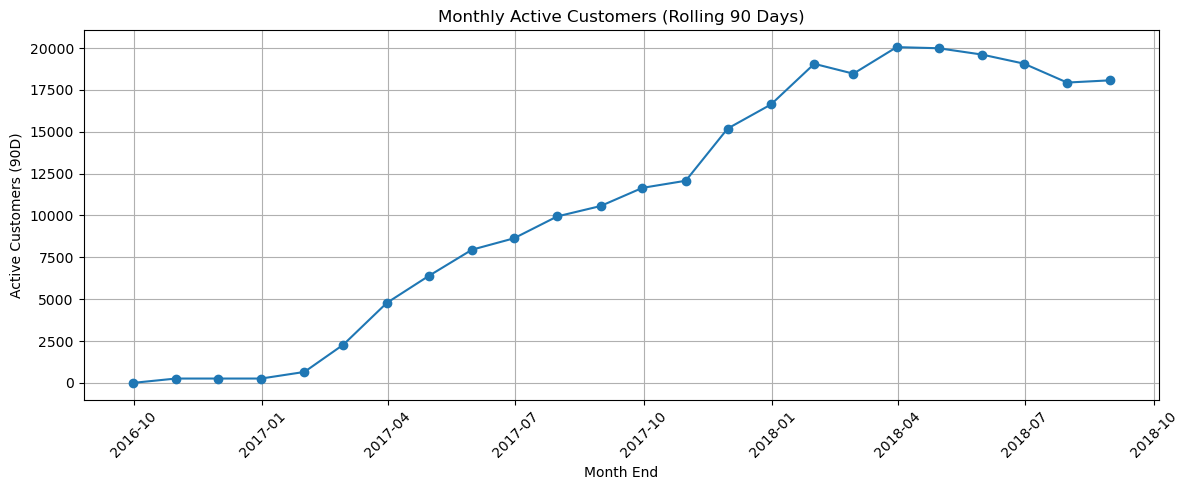

In [75]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_active_90["month_end"],
    monthly_active_90["active_customers_90"],
    marker="o"
)
plt.title("Monthly Active Customers (Rolling 90 Days)")
plt.xlabel("Month End")
plt.ylabel("Active Customers (90D)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### 5. 每月下單顧客、新客、活躍顧客、回購顧客的比例分析  
回購定義：每位顧客所有訂單，只要有兩個order_id 就算回購
| 指標                                    | 計算定義                                              | 計算邏輯說明                                               |
| ------------------------------------- | ------------------------------------------------- | ---------------------------------------------------- |
| 下單顧客 (`purchasing_customers`)         | 當月有下單的顧客數                                         | 以 `purchase_month` 分組後，計算當月 `customer_unique_id` 去重數 |
| 新客 (`new_customers`)                  | 人生第一次購買發生在本月的顧客數                                  | 若顧客的 `first_purchase_month = 當月`，則算為新客               |
| 回購顧客 (`repeat_customers`)             | 在整個資料期間內，`order_id >= 2` 的顧客，且當月有下單               | 只要該顧客整體有兩筆以上不同 `order_id`，當月出現時就被算入回購顧客              |
| 90天內再購顧客 (`repurchase_90d_customers`) | 當月某筆訂單之後 90 天內還有下一筆訂單的顧客數                         | 以訂單層級排序後，用 `shift(-1)` 找下一筆訂單；若 90 天內存在下一筆，則該顧客算入    |
| 新客比例 (`new_rate`)                     | `new_customers / purchasing_customers`            | 當月下單顧客中，新客占比                                         |
| 回購顧客比例 (`repeat_rate`)                | `repeat_customers / purchasing_customers`         | 當月下單顧客中，整體屬於 2 筆以上 `order_id` 顧客的占比                  |
| 90天內再購比例 (`repurchase_90d_rate`)      | `repurchase_90d_customers / purchasing_customers` | 當月下單顧客中，訂單後 90 天內有下一筆訂單者占比                           |


In [88]:
orders_delivered_base.columns

Index(['order_id', 'customer_id', 'customer_unique_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'purchase_month'],
      dtype='object')

In [101]:

analysis_end = pd.Timestamp("2018-05-31 15:00:00")

df = orders_delivered_base[
    ["order_id", "customer_unique_id", "order_purchase_timestamp", "purchase_month"]
].dropna(subset=["customer_unique_id", "order_purchase_timestamp"]).copy()

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["purchase_month"] = pd.to_datetime(df["purchase_month"], errors="coerce")

# 只保留到 analysis_end
df = df.loc[df["order_purchase_timestamp"] <= analysis_end].copy()

df = df.sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id"]).reset_index(drop=True)

# 每位顧客人生第一次購買月份
df["first_purchase_month"] = (
    df.groupby("customer_unique_id")["order_purchase_timestamp"]
      .transform("min")
      .dt.to_period("M")
      .dt.to_timestamp()
)

# -----------------------------------
# A1. 全域回購定義：order_id >= 2
# -----------------------------------
customer_order_cnt = (
    df.groupby("customer_unique_id")["order_id"]
      .nunique()
      .rename("total_orders")
      .reset_index()
)

customer_order_cnt["is_repeat_customer"] = customer_order_cnt["total_orders"] >= 2

df = df.merge(
    customer_order_cnt[["customer_unique_id", "is_repeat_customer"]],
    on="customer_unique_id",
    how="left"
)

# -----------------------------------
# A2. 90天內再購：下一筆 order 即算
# -----------------------------------
df["next_purchase_ts"] = (
    df.groupby("customer_unique_id")["order_purchase_timestamp"]
      .shift(-1)
)

df["has_repurchase_within_90d"] = (
    df["next_purchase_ts"].notna() &
    ((df["next_purchase_ts"] - df["order_purchase_timestamp"]) <= pd.Timedelta(days=90))
)

monthly_customer_base_v1 = (
    df.groupby("purchase_month")
      .agg(
          purchasing_customers=("customer_unique_id", "nunique"),
          new_customers=(
              "customer_unique_id",
              lambda s: s[
                  df.loc[s.index, "purchase_month"].eq(df.loc[s.index, "first_purchase_month"])
              ].nunique()
          ),
          repeat_customers=(
              "customer_unique_id",
              lambda s: s[
                  df.loc[s.index, "is_repeat_customer"]
              ].nunique()
          ),
          repurchase_90d_customers=(
              "customer_unique_id",
              lambda s: s[
                  df.loc[s.index, "has_repurchase_within_90d"]
              ].nunique()
          )
      )
      .reset_index()
      .rename(columns={"purchase_month": "month"})
      .assign(
          new_rate=lambda x: x["new_customers"] / x["purchasing_customers"],
          repeat_rate=lambda x: x["repeat_customers"] / x["purchasing_customers"],
          repurchase_90d_rate=lambda x: x["repurchase_90d_customers"] / x["purchasing_customers"]
      )
)

monthly_customer_base_v1

,month,purchasing_customers,new_customers,repeat_customers,repurchase_90d_customers,new_rate,repeat_rate,repurchase_90d_rate
0,2016-09-01,1,1,0,0,1.000000,0.000000,0.000000
1,2016-10-01,262,262,11,3,1.000000,0.041985,0.011450
2,2016-12-01,1,1,1,1,1.000000,1.000000,1.000000
3,2017-01-01,718,717,49,26,0.998607,0.068245,0.036212
4,2017-02-01,1630,1628,65,28,0.998773,0.039877,0.017178
5,2017-03-01,2508,2503,117,62,0.998006,0.046651,0.024721
6,2017-04-01,2274,2256,113,50,0.992084,0.049692,0.021988
7,2017-05-01,3479,3451,198,99,0.991952,0.056913,0.028456
8,2017-06-01,3076,3037,187,90,0.987321,0.060793,0.029259
9,2017-07-01,3802,3752,206,102,0.986849,0.054182,0.026828


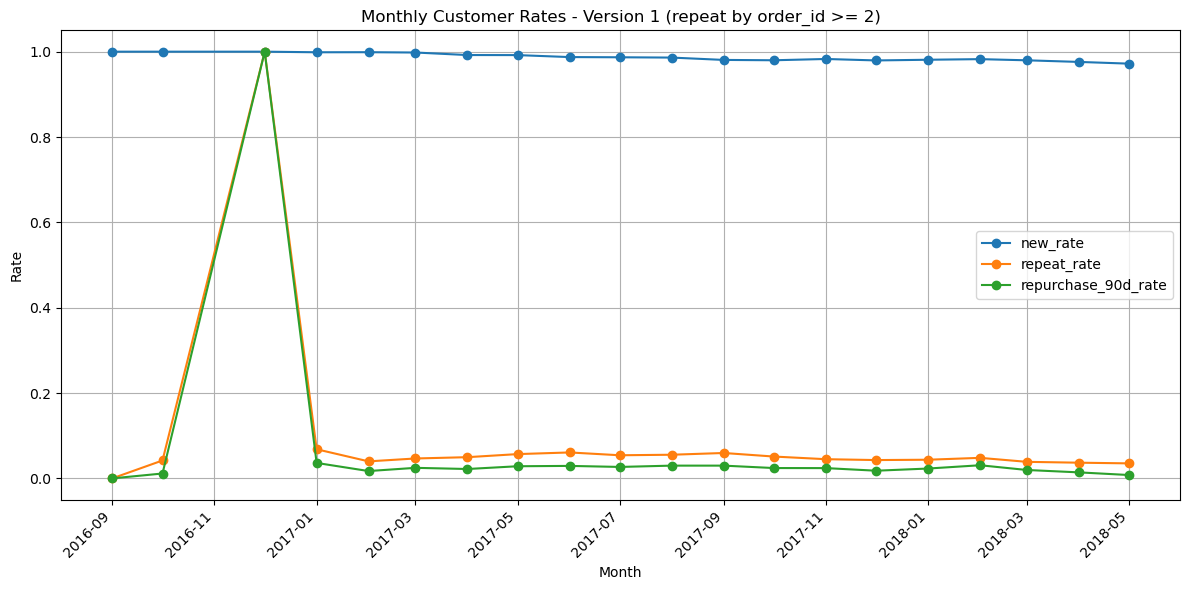

In [102]:
monthly_customer_base_v1.set_index("month")[[
    "new_rate",
    "repeat_rate",
    "repurchase_90d_rate"
]].plot(figsize=(12, 6), marker="o", grid=True)

plt.title("Monthly Customer Rates - Version 1 (repeat by order_id >= 2)")
plt.xlabel("Month")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6. 每月下單顧客、新客、活躍顧客、回購顧客的比例分析  
回購定義：每位顧客所有訂單，兩筆 order order_timestamp不同即算回購 
| 指標                                    | 計算定義                                                                                  | 計算邏輯說明                                                            |
| ------------------------------------- | ------------------------------------------------------------------------------------- | ----------------------------------------------------------------- |
| 下單顧客 (`purchasing_customers`)         | 當月有下單的顧客數                                                                             | 以 `purchase_month` 分組後，計算當月 `customer_unique_id` 去重數              |
| 新客 (`new_customers`)                  | 人生第一次購買發生在本月的顧客數                                                                      | 若顧客的 `first_purchase_month = 當月`，則算為新客                            |
| 回購顧客 (`repeat_customers`)             | 當月有下單，且在本月購買之前已經有過更早的不同 `order_purchase_timestamp` 的顧客數                               | 回購是以「不同 timestamp 的購買事件」為基礎；只有先前已有不同 timestamp 的購買事件，當月再次購買才算回購顧客 |
| 90天內再購顧客 (`repurchase_90d_customers`) | 將相同 `order_purchase_timestamp` 先合併為一次購買事件後，若該事件之後 90 天內還有下一次不同 timestamp 的購買事件，則該顧客算入 | 先在顧客層級將相同 timestamp 視為同一次購買，再用下一個不同 timestamp 判斷是否 90 天內再購        |
| 新客比例 (`new_rate`)                     | `new_customers / purchasing_customers`                                                | 當月下單顧客中，新客占比                                                      |
| 回購顧客比例 (`repeat_rate`)                | `repeat_customers / purchasing_customers`                                             | 當月下單顧客中，過去已買過且本月再次購買者占比                                           |
| 90天內再購比例 (`repurchase_90d_rate`)      | `repurchase_90d_customers / purchasing_customers`                                     | 當月下單顧客中，購買事件後 90 天內還有下一次事件者占比                                     |


In [104]:


analysis_end = pd.Timestamp("2018-05-31 15:00:00")

df = orders_delivered_base[
    ["order_id", "customer_unique_id", "order_purchase_timestamp", "purchase_month"]
].dropna(subset=["customer_unique_id", "order_purchase_timestamp"]).copy()

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["purchase_month"] = pd.to_datetime(df["purchase_month"], errors="coerce")

# 只保留到 analysis_end
df = df.loc[df["order_purchase_timestamp"] <= analysis_end].copy()

df = df.sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id"]).reset_index(drop=True)

# 每位顧客人生第一次購買月份
df["first_purchase_month"] = (
    df.groupby("customer_unique_id")["order_purchase_timestamp"]
      .transform("min")
      .dt.to_period("M")
      .dt.to_timestamp()
)

# =========================================================
# B1. 回購顧客：不同 order_purchase_timestamp >= 2 才算
# =========================================================
customer_ts_cnt = (
    df.groupby("customer_unique_id")["order_purchase_timestamp"]
      .nunique()
      .rename("distinct_purchase_ts_cnt")
      .reset_index()
)

customer_ts_cnt["is_repeat_customer"] = customer_ts_cnt["distinct_purchase_ts_cnt"] >= 2

df = df.merge(
    customer_ts_cnt[["customer_unique_id", "is_repeat_customer"]],
    on="customer_unique_id",
    how="left"
)

# =========================================================
# B2. 90天內再購顧客：
# 相同 order_purchase_timestamp 先併成一次購買事件
# 再看下一次不同 timestamp 是否在 90 天內
# =========================================================
purchase_event = (
    df[["customer_unique_id", "order_purchase_timestamp"]]
    .drop_duplicates()
    .sort_values(["customer_unique_id", "order_purchase_timestamp"])
    .reset_index(drop=True)
)

purchase_event["next_purchase_ts"] = (
    purchase_event.groupby("customer_unique_id")["order_purchase_timestamp"]
    .shift(-1)
)

purchase_event["has_repurchase_within_90d"] = (
    purchase_event["next_purchase_ts"].notna() &
    ((purchase_event["next_purchase_ts"] - purchase_event["order_purchase_timestamp"]) <= pd.Timedelta(days=90))
)

# 把「事件層級」結果 merge 回原本訂單層級
df = df.merge(
    purchase_event[
        ["customer_unique_id", "order_purchase_timestamp", "next_purchase_ts", "has_repurchase_within_90d"]
    ],
    on=["customer_unique_id", "order_purchase_timestamp"],
    how="left"
)

monthly_customer_base_v2 = (
    df.groupby("purchase_month")
      .agg(
          purchasing_customers=("customer_unique_id", "nunique"),
          new_customers=(
              "customer_unique_id",
              lambda s: s[
                  df.loc[s.index, "purchase_month"].eq(df.loc[s.index, "first_purchase_month"])
              ].nunique()
          ),
          repeat_customers=(
              "customer_unique_id",
              lambda s: s[
                  df.loc[s.index, "is_repeat_customer"]
              ].nunique()
          ),
          repurchase_90d_customers=(
              "customer_unique_id",
              lambda s: s[
                  df.loc[s.index, "has_repurchase_within_90d"]
              ].nunique()
          )
      )
      .reset_index()
      .rename(columns={"purchase_month": "month"})
      .assign(
          new_rate=lambda x: x["new_customers"] / x["purchasing_customers"],
          repeat_rate=lambda x: x["repeat_customers"] / x["purchasing_customers"],
          repurchase_90d_rate=lambda x: x["repurchase_90d_customers"] / x["purchasing_customers"]
      )
)

monthly_customer_base_v2

,month,purchasing_customers,new_customers,repeat_customers,repurchase_90d_customers,new_rate,repeat_rate,repurchase_90d_rate
0,2016-09-01,1,1,0,0,1.000000,0.000000,0.000000
1,2016-10-01,262,262,10,2,1.000000,0.038168,0.007634
2,2016-12-01,1,1,1,1,1.000000,1.000000,1.000000
3,2017-01-01,718,717,36,13,0.998607,0.050139,0.018106
4,2017-02-01,1630,1628,53,16,0.998773,0.032515,0.009816
5,2017-03-01,2508,2503,90,35,0.998006,0.035885,0.013955
6,2017-04-01,2274,2256,97,33,0.992084,0.042656,0.014512
7,2017-05-01,3479,3451,163,62,0.991952,0.046853,0.017821
8,2017-06-01,3076,3037,161,61,0.987321,0.052341,0.019831
9,2017-07-01,3802,3752,163,58,0.986849,0.042872,0.015255


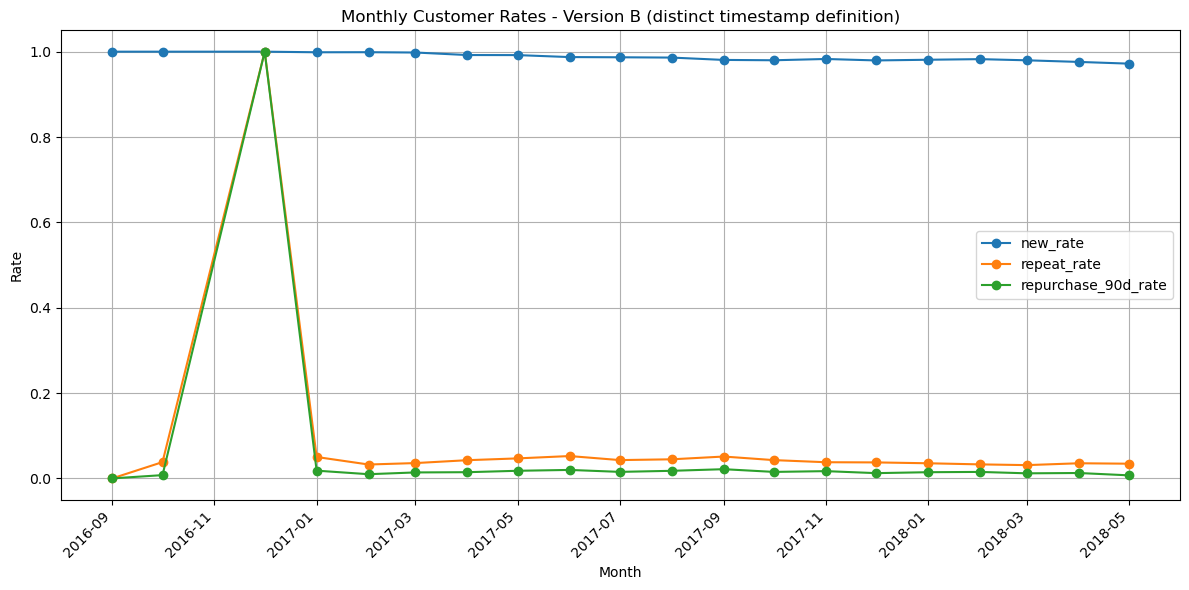

In [105]:
monthly_customer_base_v2.set_index("month")[[
    "new_rate",
    "repeat_rate",
    "repurchase_90d_rate"
]].plot(figsize=(12, 6), marker="o", grid=True)

plt.title("Monthly Customer Rates - Version B (distinct timestamp definition)")
plt.xlabel("Month")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()